# UAC Care Transition Efficiency & Placement Outcome Analytics
### Machine Learning Intern Project — Exploratory Data Analysis

**Dataset:** HHS Unaccompanied Alien Children (UAC) Program — daily reporting, Jan 2023 – Dec 2025

**Reframing:** from *capacity monitoring* (how many kids are in custody) to *process efficiency*
(how fast they move through the pipeline, where backlogs form, and whether outcomes are improving).

**KPI definitions (per project brief):**
- **Transfer Efficiency Ratio** = Transfers ÷ CBP Custody (stock)
- **Discharge Effectiveness** = Discharges ÷ HHS Care (stock)
- **Pipeline Throughput Rate** = Total exits ÷ Total entries (rolling window)
- **Backlog Accumulation Rate** = net daily accumulation across the full pipeline (rolling average)
- **Outcome Stability Score** = 1 − coefficient of variation of Discharge Effectiveness (rolling)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from uac_metrics import (
    load_data, compute_core_metrics, detect_bottlenecks, detect_stagnation,
    weekday_weekend_summary, month_over_month_summary, summary_stats,
)

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

pd.set_option('display.max_columns', 20)


## 1. Load & Clean Data

In [2]:
df = load_data("HHS_Unaccompanied_Alien_Children_Program.csv")
print(f"Rows: {len(df)}  |  Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Rows: 720  |  Date range: 2023-01-12 to 2025-12-21


,date,cbp_inflow,cbp_stock,cbp_to_hhs,hhs_stock,hhs_discharged
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0


In [3]:
# Missing values / data quality check
print("Missing values per column:")
print(df.isna().sum())
print()
print("Reporting cadence (gaps between consecutive reporting days, in calendar days):")
print(df['date'].diff().dt.days.value_counts().sort_index())


Missing values per column:
date              0
cbp_inflow        0
cbp_stock         0
cbp_to_hhs        0
hhs_stock         0
hhs_discharged    0
dtype: int64

Reporting cadence (gaps between consecutive reporting days, in calendar days):
date
1.0     558
2.0      10
3.0     122
4.0      23
5.0       3
6.0       1
7.0       1
10.0      1
Name: count, dtype: int64


**Note on cadence:** HHS reports on a rolling near-daily basis but skips weekends/holidays
intermittently (mix of 1-day and 3-day gaps). We keep the native reporting cadence rather than
forward-filling to every calendar day — forward-filling would fabricate flow data on days
nothing was reported.

## 2. Compute Process Efficiency KPIs

In [4]:
df = compute_core_metrics(df)
df = detect_bottlenecks(df)
df = detect_stagnation(df)
df[['date','cbp_stock','cbp_to_hhs','transfer_efficiency_ratio','hhs_stock','hhs_discharged','discharge_effectiveness']].tail(10)


,date,cbp_stock,cbp_to_hhs,transfer_efficiency_ratio,hhs_stock,hhs_discharged,discharge_effectiveness
710,2025-12-08,27.0,9.0,0.333333,2440.0,4.0,0.001639
711,2025-12-09,30.0,7.0,0.233333,2443.0,8.0,0.003275
712,2025-12-10,54.0,5.0,0.092593,2439.0,9.0,0.003690
713,2025-12-11,47.0,9.0,0.191489,2437.0,10.0,0.004103
714,2025-12-14,35.0,4.0,0.114286,2462.0,8.0,0.003249
715,2025-12-15,42.0,9.0,0.214286,2470.0,7.0,0.002834
716,2025-12-16,54.0,15.0,0.277778,2468.0,9.0,0.003647
717,2025-12-17,31.0,11.0,0.354839,2481.0,10.0,0.004031
718,2025-12-18,50.0,6.0,0.120000,2472.0,16.0,0.006472
719,2025-12-21,18.0,11.0,0.611111,2484.0,14.0,0.005636


**Derived KPIs and diagnostics:**
- `transfer_efficiency_ratio` = Transfers ÷ CBP Custody (stock) — turnover velocity, not vs.-inflow.
- `discharge_effectiveness` = Discharges ÷ HHS Care (stock).
- `pipeline_throughput_rate` = rolling-30-session (total HHS discharges ÷ total new CBP entries) — whole-pipeline, entry-to-exit.
- `backlog_accumulation_rate` = rolling-14-session avg of (new entries − final exits) — children/session net-added to the unresolved pipeline.
- `outcome_stability_score` = 1 − CV(discharge_effectiveness) over a rolling 30-session window.
- `cbp_los_days_est` / `hhs_los_days_est` = estimated average length of stay via Little's Law (Stock ÷ 30-session rolling outflow rate).
- `cbp_bottleneck` / `hhs_bottleneck` = level-based flag: stock >1.5 rolling z-scores above 60-session baseline AND still net-accumulating.
- `is_stagnation` = flow-based flag: Discharge Effectiveness below its own trailing 90-session median for 5+ consecutive sessions.

## 3. Summary Statistics

In [5]:
stats = summary_stats(df)
for k, v in stats.items():
    print(f"{k:35s}: {v}")


date_range                         : (Timestamp('2023-01-12 00:00:00'), Timestamp('2025-12-21 00:00:00'))
n_reporting_days                   : 720
latest_date                        : 2025-12-21 00:00:00
latest_cbp_stock                   : 18.0
latest_hhs_stock                   : 2484.0
avg_transfer_efficiency_30d        : 0.2750315249991578
avg_discharge_effectiveness_30d    : 0.003751217988310249
avg_pipeline_throughput_30d        : 1.3453366848374841
avg_backlog_accumulation_30d       : -2.0595238095238098
avg_outcome_stability_30d          : 0.5555752492834376
avg_transfer_efficiency_90d        : 0.3234987685338772
avg_discharge_effectiveness_90d    : 0.0047994825606137706
avg_cbp_los_days_30d               : 3.5559235138901495
avg_hhs_los_days_30d               : 251.50792611296592
total_bottleneck_days_cbp          : 26
total_bottleneck_days_hhs          : 41
total_stagnation_days              : 132


## 4. Care Pipeline Flow Visualization

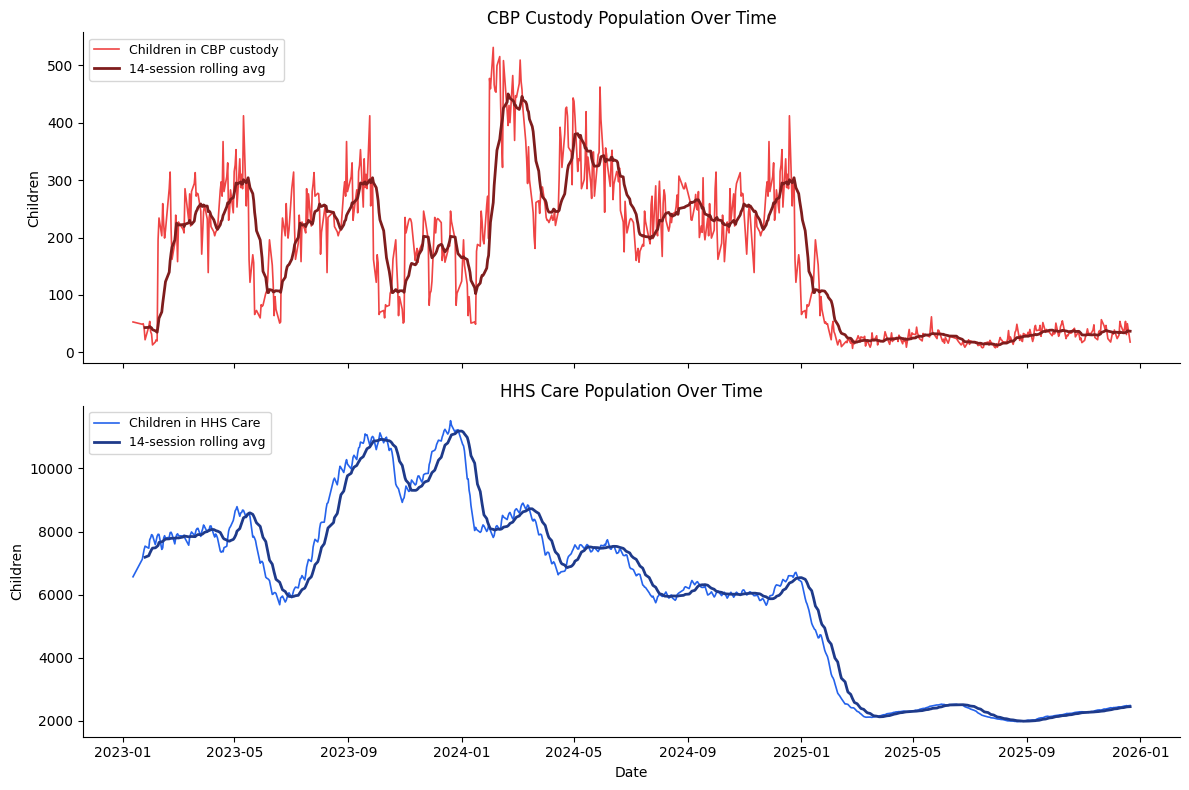

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['date'], df['cbp_stock'], color='#EF4444', lw=1.2, label='Children in CBP custody')
axes[0].plot(df['date'], df['cbp_stock_roll14'], color='#7F1D1D', lw=2, label='14-session rolling avg')
axes[0].set_title('CBP Custody Population Over Time')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_ylabel('Children')

axes[1].plot(df['date'], df['hhs_stock'], color='#2563EB', lw=1.2, label='Children in HHS Care')
axes[1].plot(df['date'], df['hhs_stock_roll14'], color='#1E3A8A', lw=2, label='14-session rolling avg')
axes[1].set_title('HHS Care Population Over Time')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].set_ylabel('Children')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('chart_pipeline_flow.png', dpi=130)
plt.show()


## 5. Transfer & Discharge Efficiency Panels

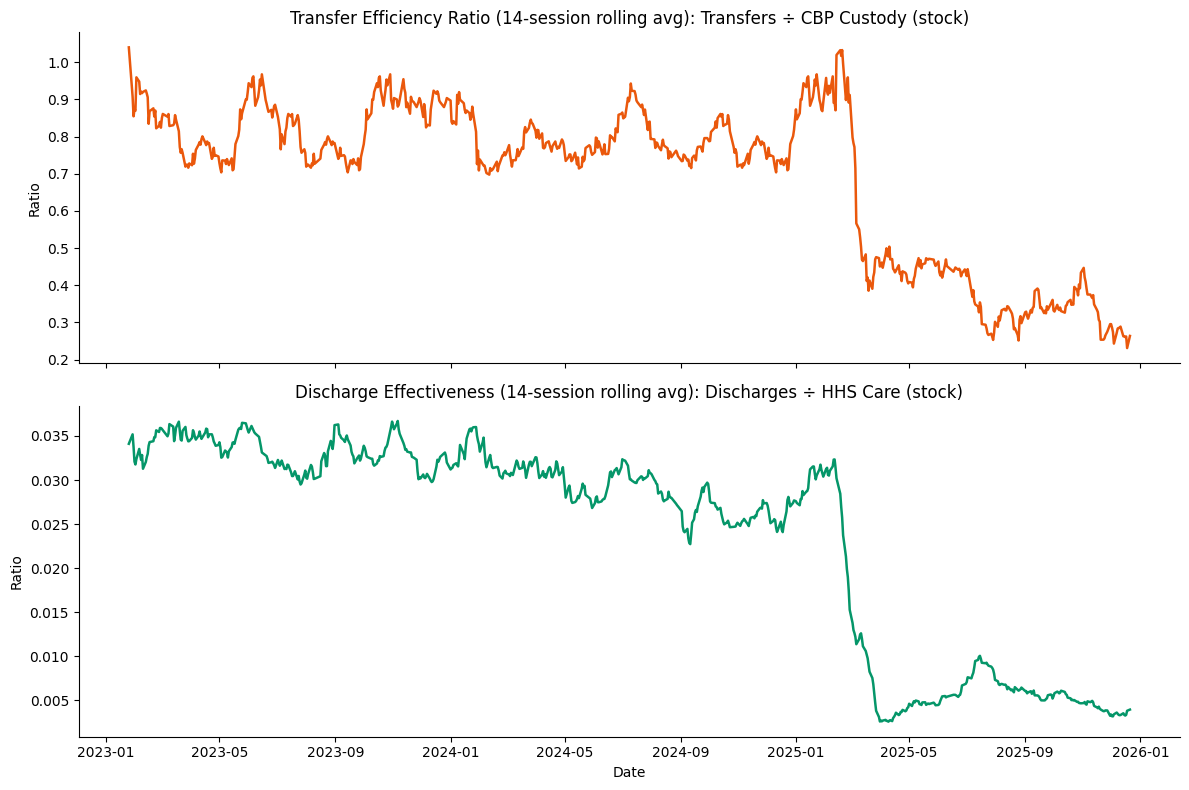

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['date'], df['transfer_efficiency_ratio_roll14'], color='#EA580C', lw=1.8)
axes[0].set_title('Transfer Efficiency Ratio (14-session rolling avg): Transfers \u00f7 CBP Custody (stock)')
axes[0].set_ylabel('Ratio')

axes[1].plot(df['date'], df['discharge_effectiveness_roll14'], color='#059669', lw=1.8)
axes[1].set_title('Discharge Effectiveness (14-session rolling avg): Discharges \u00f7 HHS Care (stock)')
axes[1].set_ylabel('Ratio')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('chart_efficiency_ratios.png', dpi=130)
plt.show()


**Reading these panels:** these are turnover-velocity ratios against each stage's own current
stock, not against inflow. A rising ratio means that stage is processing a larger share of its own
backlog per session (faster throughput per child in the queue).

## 5b. Pipeline Throughput Rate & Backlog Accumulation Rate

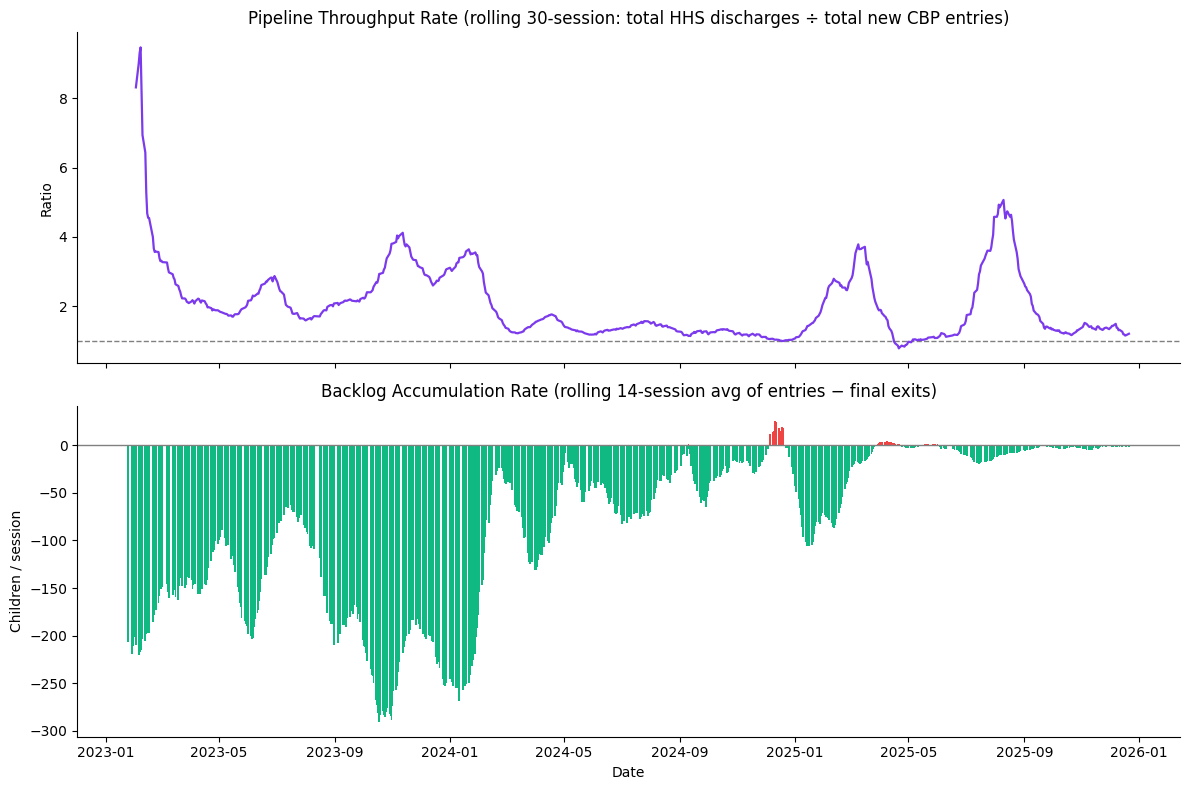

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].axhline(1.0, color='gray', ls='--', lw=1)
axes[0].plot(df['date'], df['pipeline_throughput_rate'], color='#7C3AED', lw=1.6)
axes[0].set_title('Pipeline Throughput Rate (rolling 30-session: total HHS discharges \u00f7 total new CBP entries)')
axes[0].set_ylabel('Ratio')

colors = np.where(df['backlog_accumulation_rate'] > 0, '#EF4444', '#10B981')
axes[1].axhline(0, color='gray', lw=1)
axes[1].bar(df['date'], df['backlog_accumulation_rate'], color=colors, width=2)
axes[1].set_title('Backlog Accumulation Rate (rolling 14-session avg of entries \u2212 final exits)')
axes[1].set_ylabel('Children / session')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('chart_throughput_backlog.png', dpi=130)
plt.show()


**Pipeline Throughput Rate** answers the end-to-end question directly: is the whole system,
door to door, netting children out as fast as they come in? **Backlog Accumulation Rate** gives the
same picture in absolute terms — how many children per session are being net-added to (red) or
drained from (green) the unresolved pipeline.

## 6. Bottleneck Detection

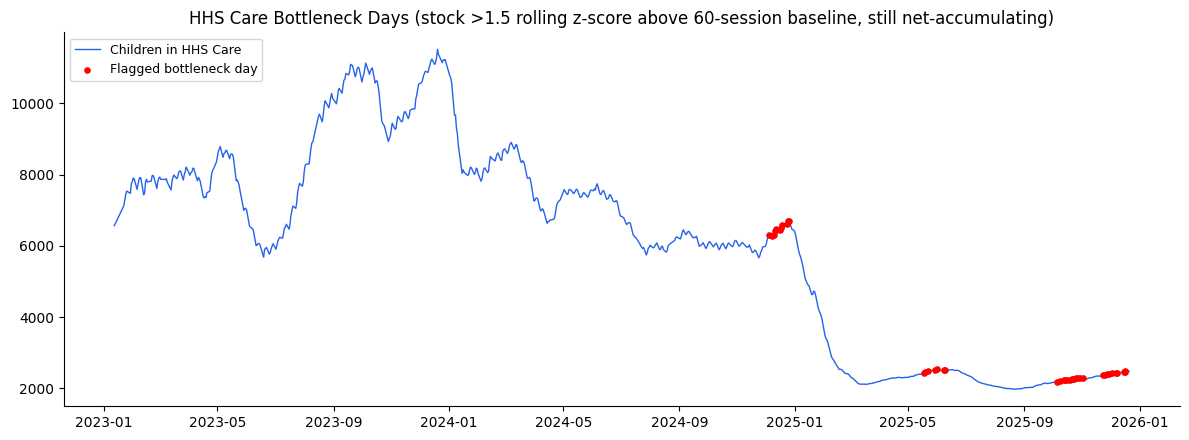

Total flagged CBP bottleneck days: 26
Total flagged HHS bottleneck days: 41


In [9]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df['date'], df['hhs_stock'], color='#2563EB', lw=1, label='Children in HHS Care')
bottleneck_days = df[df['hhs_bottleneck']]
ax.scatter(bottleneck_days['date'], bottleneck_days['hhs_stock'], color='red', s=14, zorder=5, label='Flagged bottleneck day')
ax.set_title('HHS Care Bottleneck Days (stock >1.5 rolling z-score above 60-session baseline, still net-accumulating)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart_bottlenecks_hhs.png', dpi=130)
plt.show()

print(f"Total flagged CBP bottleneck days: {df['cbp_bottleneck'].sum()}")
print(f"Total flagged HHS bottleneck days: {df['hhs_bottleneck'].sum()}")


In [10]:
# When did the worst bottleneck clusters occur? Group consecutive flagged days into episodes.
def bottleneck_episodes(df, col):
    flagged = df[df[col]].copy()
    if flagged.empty:
        return pd.DataFrame()
    flagged['gap'] = flagged['date'].diff().dt.days.fillna(99)
    flagged['episode'] = (flagged['gap'] > 7).cumsum()
    ep = flagged.groupby('episode').agg(start=('date','min'), end=('date','max'), days_flagged=('date','count'))
    return ep.sort_values('start')

print("HHS bottleneck episodes:")
bottleneck_episodes(df, 'hhs_bottleneck')


HHS bottleneck episodes:


,start,end,days_flagged
episode,,,
1,2024-12-05,2024-12-26,11
2,2025-05-18,2025-06-09,7
3,2025-10-06,2025-11-02,13
4,2025-11-23,2025-12-17,10


## 7. Stagnation Detection (flow-based, distinct from level-based bottlenecks)

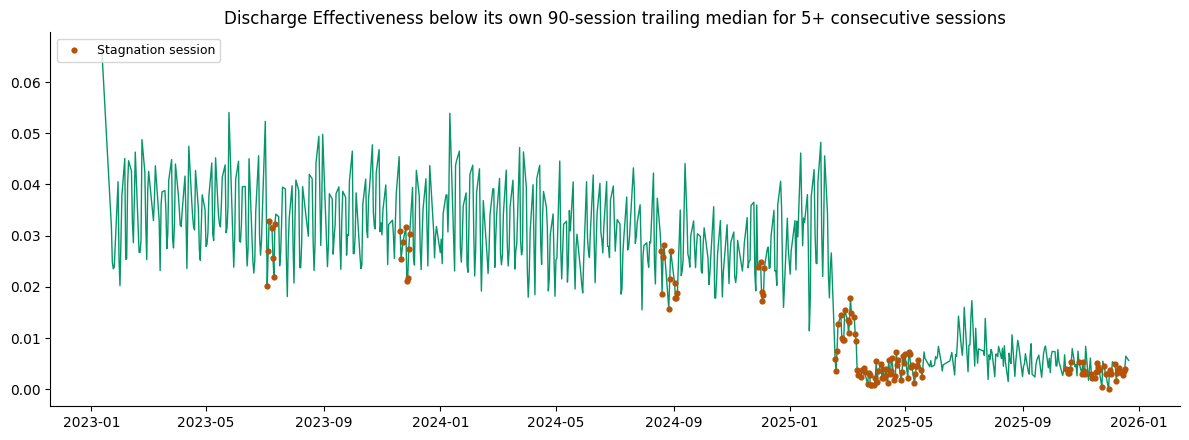

Total flagged stagnation sessions: 132 out of 720


In [11]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df['date'], df['discharge_effectiveness'], color='#059669', lw=1)
stag = df[df['is_stagnation']]
ax.scatter(stag['date'], stag['discharge_effectiveness'], color='#B45309', s=12, zorder=5, label='Stagnation session')
ax.set_title('Discharge Effectiveness below its own 90-session trailing median for 5+ consecutive sessions')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart_stagnation.png', dpi=130)
plt.show()

print(f"Total flagged stagnation sessions: {df['is_stagnation'].sum()} out of {len(df)}")


## 8. Temporal & Pattern Analysis

In [12]:
print("Weekday vs. weekend transition speed:")
ww = weekday_weekend_summary(df)
ww


Weekday vs. weekend transition speed:


,avg_transfer_efficiency,avg_discharge_effectiveness,avg_cbp_inflow,avg_cbp_to_hhs,avg_hhs_discharged,sessions
is_weekend,,,,,,
Weekday,0.689,0.023,94.688,128.361,166.195,590
Weekend,0.700,0.028,88.238,130.062,206.138,130


**Note:** this dataset reports far fewer Friday/Saturday sessions than other weekdays
(near-zero Friday, no Saturday). "Weekend" here is effectively driven by Sunday sessions, so
treat the weekday/weekend comparison as indicative rather than a clean 5-vs-2 split.

In [13]:
print("Month-over-month placement trends (most recent 12 months):")
mom = month_over_month_summary(df)
mom.tail(12)


Month-over-month placement trends (most recent 12 months):


,total_discharged,total_transferred,total_apprehended,avg_transfer_efficiency,avg_discharge_effectiveness,avg_pipeline_throughput,avg_outcome_stability,sessions
month,,,,,,,,
2025-01,3330.0,1750.0,1311.0,0.916,0.031,1.467,0.744,22
2025-02,1160.0,341.0,312.0,0.908,0.021,2.561,0.642,19
2025-03,309.0,190.0,169.0,0.429,0.006,3.033,0.349,22
2025-04,203.0,230.0,189.0,0.431,0.004,1.226,0.297,23
2025-05,205.0,252.0,217.0,0.446,0.005,1.042,0.534,18
2025-06,281.0,138.0,123.0,0.441,0.007,1.226,0.632,17
2025-07,396.0,88.0,70.0,0.305,0.009,2.930,0.527,21
2025-08,254.0,147.0,107.0,0.311,0.006,4.263,0.556,20
2025-09,237.0,260.0,204.0,0.343,0.005,1.840,0.590,22


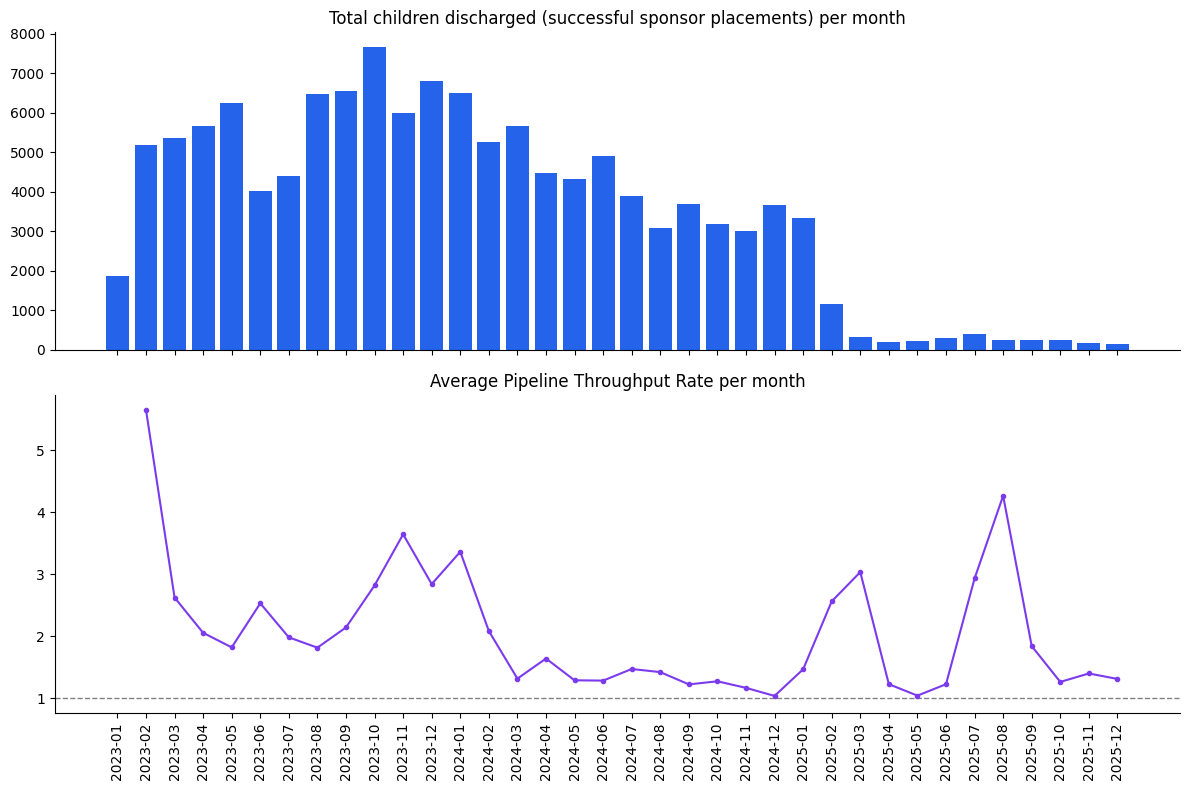

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].bar(mom.index.astype(str), mom['total_discharged'], color='#2563EB')
axes[0].set_title('Total children discharged (successful sponsor placements) per month')
axes[0].tick_params(axis='x', rotation=90)

axes[1].axhline(1.0, color='gray', ls='--', lw=1)
axes[1].plot(mom.index.astype(str), mom['avg_pipeline_throughput'], color='#7C3AED', marker='o', ms=3)
axes[1].set_title('Average Pipeline Throughput Rate per month')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('chart_month_over_month.png', dpi=130)
plt.show()


## 9. Outcome Trend Analysis — Is the System Improving or Deteriorating?

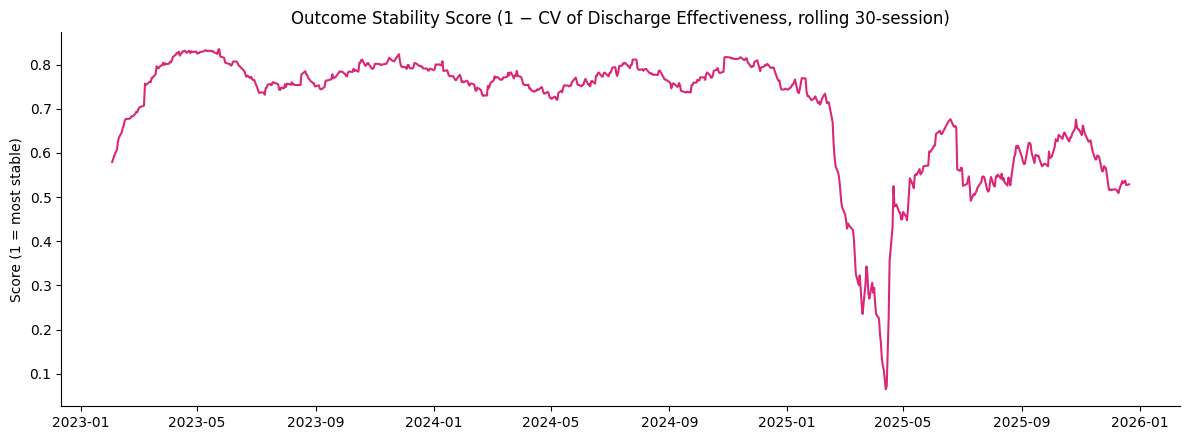

In [15]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df['date'], df['outcome_stability_score'], color='#DB2777', lw=1.5)
ax.set_title('Outcome Stability Score (1 \u2212 CV of Discharge Effectiveness, rolling 30-session)')
ax.set_ylabel('Score (1 = most stable)')
plt.tight_layout()
plt.savefig('chart_outcome_stability.png', dpi=130)
plt.show()


In [16]:
# Split into ~6-month eras and compare average KPIs + estimated length of stay
df['era'] = df['date'].dt.to_period('6M').astype(str)
era_summary = df.groupby('era').agg(
    avg_transfer_efficiency=('transfer_efficiency_ratio','mean'),
    avg_discharge_effectiveness=('discharge_effectiveness','mean'),
    avg_pipeline_throughput=('pipeline_throughput_rate','mean'),
    avg_outcome_stability=('outcome_stability_score','mean'),
    avg_hhs_los_days=('hhs_los_days_est','mean'),
    avg_hhs_stock=('hhs_stock','mean'),
    bottleneck_days=('hhs_bottleneck','sum'),
    stagnation_days=('is_stagnation','sum'),
).round(3)
era_summary


,avg_transfer_efficiency,avg_discharge_effectiveness,avg_pipeline_throughput,avg_outcome_stability,avg_hhs_los_days,avg_hhs_stock,bottleneck_days,stagnation_days
era,,,,,,,,
2023-01,0.873,0.032,NaN,NaN,NaN,7369.625,0,0
2023-02,0.870,0.035,5.648,0.653,30.687,7795.789,0,0
2023-03,0.752,0.036,2.623,0.771,29.282,7945.368,0,0
2023-04,0.774,0.034,2.054,0.823,28.264,7842.667,0,0
2023-05,0.847,0.035,1.820,0.826,29.509,8187.136,0,0
2023-06,0.852,0.033,2.530,0.788,23.822,6136.450,0,0
2023-07,0.785,0.031,1.981,0.748,33.984,6828.095,0,7
2023-08,0.775,0.034,1.815,0.763,39.249,9347.900,0,0
2023-09,0.745,0.032,2.141,0.767,33.015,10701.316,0,0


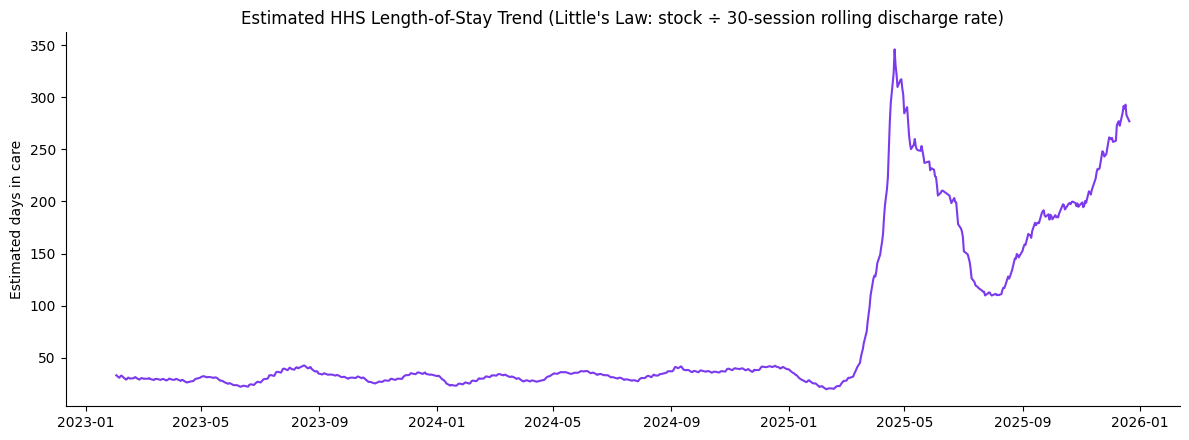

In [17]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df['date'], df['hhs_los_days_est'], color='#7C3AED', lw=1.5)
ax.set_title('Estimated HHS Length-of-Stay Trend (Little\'s Law: stock \u00f7 30-session rolling discharge rate)')
ax.set_ylabel('Estimated days in care')
plt.tight_layout()
plt.savefig('chart_los_trend.png', dpi=130)
plt.show()


## 10. Key Findings

Findings are generated dynamically from the computed metrics below — re-run this cell after any
data refresh to keep the summary current.

In [18]:
latest_era = era_summary.index[-1]
# Skip the very first era for the LOS trend comparison if it lacks enough warm-up data
# (the 30-session rolling window needs ~10 sessions before it produces a value)
los_eras = era_summary['avg_hhs_los_days'].dropna()
first_era_with_los = los_eras.index[0]

print("=== HEADLINE FINDINGS ===")
print(f"1. Transfer Efficiency Ratio: {stats['avg_transfer_efficiency_30d']:.2f} over the last 30 reporting sessions (Transfers \u00f7 CBP Custody stock)")
print(f"2. Discharge Effectiveness: {stats['avg_discharge_effectiveness_30d']:.3f} over the last 30 reporting sessions (Discharges \u00f7 HHS Care stock)")
print(f"3. Pipeline Throughput Rate: {stats['avg_pipeline_throughput_30d']:.2f}x (rolling 30-session total exits \u00f7 total entries)")
print(f"4. Backlog Accumulation Rate: {stats['avg_backlog_accumulation_30d']:+.1f} children/session (rolling 14-session avg)")
print(f"5. Outcome Stability Score: {stats['avg_outcome_stability_30d']:.2f} (1 = perfectly consistent placement outcomes)")
print(f"6. Estimated average CBP dwell time: {stats['avg_cbp_los_days_30d']:.1f} days")
print(f"7. Estimated average HHS length of stay: {stats['avg_hhs_los_days_30d']:.0f} days")
print(f"8. Bottleneck sessions flagged: {stats['total_bottleneck_days_cbp']} (CBP), {stats['total_bottleneck_days_hhs']} (HHS) out of {stats['n_reporting_days']}")
print(f"9. Stagnation sessions flagged: {stats['total_stagnation_days']} out of {stats['n_reporting_days']}")
print(f"10. HHS length-of-stay trend, earliest available era ({first_era_with_los}) vs latest era ({latest_era}): "
      f"{los_eras.iloc[0]:.0f} \u2192 {era_summary.loc[latest_era,'avg_hhs_los_days']:.0f} days")
print(f"    (Note: era {era_summary.index[0]} excluded from this comparison \u2014 only {len(df[df['era']==era_summary.index[0]])} reporting")
print(f"    sessions fell in that partial period, not enough for the 30-session rolling LOS estimate to warm up.)")


=== HEADLINE FINDINGS ===
1. Transfer Efficiency Ratio: 0.28 over the last 30 reporting sessions (Transfers ÷ CBP Custody stock)
2. Discharge Effectiveness: 0.004 over the last 30 reporting sessions (Discharges ÷ HHS Care stock)
3. Pipeline Throughput Rate: 1.35x (rolling 30-session total exits ÷ total entries)
4. Backlog Accumulation Rate: -2.1 children/session (rolling 14-session avg)
5. Outcome Stability Score: 0.56 (1 = perfectly consistent placement outcomes)
6. Estimated average CBP dwell time: 3.6 days
7. Estimated average HHS length of stay: 252 days
8. Bottleneck sessions flagged: 26 (CBP), 41 (HHS) out of 720
9. Stagnation sessions flagged: 132 out of 720
10. HHS length-of-stay trend, earliest available era (2023-02) vs latest era (2025-12): 31 → 274 days
    (Note: era 2023-01 excluded from this comparison — only 8 reporting
    sessions fell in that partial period, not enough for the 30-session rolling LOS estimate to warm up.)


In [19]:
# Export enriched dataset for the Streamlit app
df.to_csv('uac_enriched.csv', index=False)
print("Saved uac_enriched.csv:", df.shape)


Saved uac_enriched.csv: (720, 35)
